<a href="https://colab.research.google.com/github/josenomberto/UTEC-CDIAV3-MCD8009/blob/main/laboratorio_3_alum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MCD8009: Data Discovery - Laboratorio 3

**Integrantes**

| N° | Código | Nombres |  Contribución (0% - 100%) |
|----|--------|---------|---------------------------|
| 1  |        | José Carlos Nomberto        | 100                           |
| 2  |        |         |                           |
| 3  |        |         |                           |
| 4  |        |         |                           |

### Indicaciones

- El laboratorio podrá resolverse de manera **individual o en equipos de hasta cuatro (4) personas**. Deberán completar los datos de todos los integrantes, y **una sola persona realizará la entrega del archivo ipynb**.

- Salvo que se indique explícitamente lo contrario, no se prohibe el uso de herramientas de Inteligencia Artificial Generativa, siempre que los integrantes comprendan y puedan explicar el proceso y los resultados obtenidos. **Las respuestas no deben consistir en transcripciones literales de resultados generados por estas herramientas, sino evidenciar comprensión del tema por parte del estudiante o del equipo.**

- En caso de utilizar herramientas de IA Generativa, cada equipo es responsable de verificar la coherencia de las respuestas presentadas. Si se detectan errores, inconsistencias o falta de comprensión, la pregunta podrá ser anulada sin derecho a reclamo.

- En todos los casos, deberá completarse la **Declaración de Uso de IA Generativa.**

- Pueden agregar libremente celdas de código o de Markdown según lo consideren conveniente.

### Declaración de uso de IA Generativa
- Indicar de manera breve la(s) herramienta(s) y/o modelo(s) de IA Generativa utilizados, especificando en qué pregunta(s) se emplearon y con qué propósito.
- En caso no se haya usado, también indicarlo.

* En la pregunta 2.2, se usó Google Gemini para definir la función mahalanobis correcta, ya que al usar arrays y por dimensionalidad no se sigue el orden de la función matemática en el cálculo de la distancia de Mahalanobis, sino a la inversa
* En la pregunta 3, se usó Google Gemini, para encontrar el formato de regex correcto para aplicar en las reglas 1, 2 y 3

## INICIO DEL LABORATORIO

### Parte 1: Transformaciones (4 puntos)

En clase discutimos la posibilidad de aplicar transformaciones a las variables. Estas transformaciones pueden ayudar a normalizar la distribución y facilitar la detección de valores atípicos, especialmente en datos con colas largas o asimetría. Algunas de las [transformaciones más comunes](https://www.marsja.se/transform-skewed-data-using-square-root-log-box-cox-methods-in-python/) incluyen:

- [Transformación logarítmica](https://medium.com/@kyawsawhtoon/log-transformation-purpose-and-interpretation-9444b4b049c9)
- Transformación de raíz cuadrada
- [Transformación de Box-Cox](https://es.wikipedia.org/wiki/Transformaci%C3%B3n_Box-Cox)
- [Transformación de Yeo-Johnson](https://feature-engine.trainindata.com/en/1.8.x/user_guide/transformation/YeoJohnsonTransformer.html)

| Transformación    | Reduce colas largas | Permite valores negativos | Mejora la normalidad |
|------------------|--------------------|--------------------------|---------------------|
| **Logarítmica**  | ✅ Sí              | ❌ No                    | ✅ Sí               |
| **Raíz cuadrada** | ✅ Moderado       | ❌ No                    | ✅ Parcialmente     |
| **Box-Cox**      | ✅ Automático      | ❌ No                    | ✅ Sí               |
| **Yeo-Johnson**  | ✅ Automático      | ✅ Sí                    | ✅ Sí               |

Una manera práctica (rule-of-thumb) es usar el siguiente criterio:

- Si los datos son sesgados a la derecha: Logarítmica, Box-Cox o raíz cuadrada.
- Si hay valores negativos: Yeo-Johnson o raíz cúbica.
- Si no se sabe qué transformación aplicar: Box-Cox o Yeo-Johnson.

Vamos a continuar con el dataset `Salaries.csv` del laboratorio 2. Nuevamente nuestra variable de interés será "TotalPayBenefits" y vamos a volver considerar los salarios de los empleados en el año 2014 y Status "Full Time" (FT) únicamente. Ejecute estos filtros para el análisis. Agregue 4 columnas al dataset, cada una con su respectiva transformación:

- Logarítmica
- Raíz cuadrada
- Box-Cox
- Yeo-Johnson

Grafique la distribución original + las 4 distribuciones resultantes y comente qué observa. ¿Se ven diferencias entre los 4 métodos? (mire tanto la forma de la distribución resultante como la escala)



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from pathlib import Path
from IPython.display import Image

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import LocalOutlierFactor
from scipy.spatial.distance import mahalanobis
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from scipy.stats import chi2
from sklearn.cluster import DBSCAN
from sklearn.datasets import fetch_openml

In [2]:
salaries = pd.read_csv("Salaries.csv", low_memory=False)
salaries.head()

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
0,1,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0.0,400184.25,NaN,567595.43,567595.43,2011,NaN,San Francisco,NaN
1,2,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),155966.02,245131.88,137811.38,NaN,538909.28,538909.28,2011,NaN,San Francisco,NaN
2,3,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT),212739.13,106088.18,16452.6,NaN,335279.91,335279.91,2011,NaN,San Francisco,NaN
3,4,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,77916.0,56120.71,198306.9,NaN,332343.61,332343.61,2011,NaN,San Francisco,NaN
4,5,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",134401.6,9737.0,182234.59,NaN,326373.19,326373.19,2011,NaN,San Francisco,NaN


In [3]:
#salaries_filtered = salaries[(salaries["Year"] == 2014) & (salaries["Status"] == "FT")]
salaries_filtered = salaries[(salaries["Year"] == 2014)]
salaries_filtered = salaries_filtered[(salaries_filtered["Status"] == "FT")]
salaries_filtered.head()

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
110532,110533,Amy P Hart,Asst Med Examiner,318835.49,10712.95,60563.54,89540.23,390111.98,479652.21,2014,NaN,San Francisco,FT
110534,110535,Gregory P Suhr,Chief of Police,307450.04,0.00,19266.72,91302.46,326716.76,418019.22,2014,NaN,San Francisco,FT
110535,110536,Joanne M Hayes-White,"Chief, Fire Department",302068.00,0.00,24165.44,91201.66,326233.44,417435.10,2014,NaN,San Francisco,FT
110536,110537,Ellen G Moffatt,Asst Med Examiner,270222.04,6009.22,67956.20,71580.48,344187.46,415767.94,2014,NaN,San Francisco,FT
110537,110538,John L Martin,Dept Head V,311298.55,0.00,0.00,89772.32,311298.55,401070.87,2014,NaN,San Francisco,FT


Transformación Logaritmica

In [4]:
salaries_filtered["TotalPayBenefits_log"] = np.log1p(salaries_filtered["TotalPayBenefits"])
salaries_filtered

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status,TotalPayBenefits_log
110532,110533,Amy P Hart,Asst Med Examiner,318835.49,10712.95,60563.54,89540.23,390111.98,479652.21,2014,NaN,San Francisco,FT,13.080819
110534,110535,Gregory P Suhr,Chief of Police,307450.04,0.00,19266.72,91302.46,326716.76,418019.22,2014,NaN,San Francisco,FT,12.943285
110535,110536,Joanne M Hayes-White,"Chief, Fire Department",302068.00,0.00,24165.44,91201.66,326233.44,417435.10,2014,NaN,San Francisco,FT,12.941887
110536,110537,Ellen G Moffatt,Asst Med Examiner,270222.04,6009.22,67956.20,71580.48,344187.46,415767.94,2014,NaN,San Francisco,FT,12.937885
110537,110538,John L Martin,Dept Head V,311298.55,0.00,0.00,89772.32,311298.55,401070.87,2014,NaN,San Francisco,FT,12.901896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139066,139067,Nasan M Snell,Public Svc Aide-Public Works,26653.98,0.00,0.00,18032.01,26653.98,44685.99,2014,NaN,San Francisco,FT,10.707438
139355,139356,Eddie Ellenberg Iv,Environmental Service Worker,31856.71,1529.52,350.99,7916.24,33737.22,41653.46,2014,NaN,San Francisco,FT,10.637164
139404,139405,Bernard O Sices,Environmental Service Worker,31592.80,1274.80,178.50,8144.01,33046.10,41190.11,2014,NaN,San Francisco,FT,10.625978
139855,139856,Julie Y Zhen,Public Svc Aide-Public Works,27980.52,349.54,777.30,7568.15,29107.36,36675.51,2014,NaN,San Francisco,FT,10.509892


Transformación Raiz Cuadrada

In [5]:
#Transformación Raiz Cuadrada
salaries_filtered["TotalPayBenefits_sqrt"] = np.sqrt(salaries_filtered["TotalPayBenefits"])
salaries_filtered

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status,TotalPayBenefits_log,TotalPayBenefits_sqrt
110532,110533,Amy P Hart,Asst Med Examiner,318835.49,10712.95,60563.54,89540.23,390111.98,479652.21,2014,NaN,San Francisco,FT,13.080819,692.569282
110534,110535,Gregory P Suhr,Chief of Police,307450.04,0.00,19266.72,91302.46,326716.76,418019.22,2014,NaN,San Francisco,FT,12.943285,646.544059
110535,110536,Joanne M Hayes-White,"Chief, Fire Department",302068.00,0.00,24165.44,91201.66,326233.44,417435.10,2014,NaN,San Francisco,FT,12.941887,646.092176
110536,110537,Ellen G Moffatt,Asst Med Examiner,270222.04,6009.22,67956.20,71580.48,344187.46,415767.94,2014,NaN,San Francisco,FT,12.937885,644.800698
110537,110538,John L Martin,Dept Head V,311298.55,0.00,0.00,89772.32,311298.55,401070.87,2014,NaN,San Francisco,FT,12.901896,633.301563
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139066,139067,Nasan M Snell,Public Svc Aide-Public Works,26653.98,0.00,0.00,18032.01,26653.98,44685.99,2014,NaN,San Francisco,FT,10.707438,211.390610
139355,139356,Eddie Ellenberg Iv,Environmental Service Worker,31856.71,1529.52,350.99,7916.24,33737.22,41653.46,2014,NaN,San Francisco,FT,10.637164,204.091793
139404,139405,Bernard O Sices,Environmental Service Worker,31592.80,1274.80,178.50,8144.01,33046.10,41190.11,2014,NaN,San Francisco,FT,10.625978,202.953468
139855,139856,Julie Y Zhen,Public Svc Aide-Public Works,27980.52,349.54,777.30,7568.15,29107.36,36675.51,2014,NaN,San Francisco,FT,10.509892,191.508512


Transformación Box-Cox

In [6]:
salaries_filtered["TotalPayBenefits_boxcox"] = stats.boxcox(salaries_filtered["TotalPayBenefits"])[0]
salaries_filtered

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status,TotalPayBenefits_log,TotalPayBenefits_sqrt,TotalPayBenefits_boxcox
110532,110533,Amy P Hart,Asst Med Examiner,318835.49,10712.95,60563.54,89540.23,390111.98,479652.21,2014,NaN,San Francisco,FT,13.080819,692.569282,3.012142
110534,110535,Gregory P Suhr,Chief of Police,307450.04,0.00,19266.72,91302.46,326716.76,418019.22,2014,NaN,San Francisco,FT,12.943285,646.544059,3.010200
110535,110536,Joanne M Hayes-White,"Chief, Fire Department",302068.00,0.00,24165.44,91201.66,326233.44,417435.10,2014,NaN,San Francisco,FT,12.941887,646.092176,3.010180
110536,110537,Ellen G Moffatt,Asst Med Examiner,270222.04,6009.22,67956.20,71580.48,344187.46,415767.94,2014,NaN,San Francisco,FT,12.937885,644.800698,3.010122
110537,110538,John L Martin,Dept Head V,311298.55,0.00,0.00,89772.32,311298.55,401070.87,2014,NaN,San Francisco,FT,12.901896,633.301563,3.009599
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139066,139067,Nasan M Snell,Public Svc Aide-Public Works,26653.98,0.00,0.00,18032.01,26653.98,44685.99,2014,NaN,San Francisco,FT,10.707438,211.390610,2.962596
139355,139356,Eddie Ellenberg Iv,Environmental Service Worker,31856.71,1529.52,350.99,7916.24,33737.22,41653.46,2014,NaN,San Francisco,FT,10.637164,204.091793,2.960462
139404,139405,Bernard O Sices,Environmental Service Worker,31592.80,1274.80,178.50,8144.01,33046.10,41190.11,2014,NaN,San Francisco,FT,10.625978,202.953468,2.960117
139855,139856,Julie Y Zhen,Public Svc Aide-Public Works,27980.52,349.54,777.30,7568.15,29107.36,36675.51,2014,NaN,San Francisco,FT,10.509892,191.508512,2.956469


Transformación Yeo-Johnson

In [7]:
#Transformación Yeo-Johnson
salaries_filtered["TotalPayBenefits_yeojohnson"] = stats.yeojohnson(salaries_filtered["TotalPayBenefits"])[0]
salaries_filtered

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status,TotalPayBenefits_log,TotalPayBenefits_sqrt,TotalPayBenefits_boxcox,TotalPayBenefits_yeojohnson
110532,110533,Amy P Hart,Asst Med Examiner,318835.49,10712.95,60563.54,89540.23,390111.98,479652.21,2014,NaN,San Francisco,FT,13.080819,692.569282,3.012142,3.012054
110534,110535,Gregory P Suhr,Chief of Police,307450.04,0.00,19266.72,91302.46,326716.76,418019.22,2014,NaN,San Francisco,FT,12.943285,646.544059,3.010200,3.010113
110535,110536,Joanne M Hayes-White,"Chief, Fire Department",302068.00,0.00,24165.44,91201.66,326233.44,417435.10,2014,NaN,San Francisco,FT,12.941887,646.092176,3.010180,3.010092
110536,110537,Ellen G Moffatt,Asst Med Examiner,270222.04,6009.22,67956.20,71580.48,344187.46,415767.94,2014,NaN,San Francisco,FT,12.937885,644.800698,3.010122,3.010034
110537,110538,John L Martin,Dept Head V,311298.55,0.00,0.00,89772.32,311298.55,401070.87,2014,NaN,San Francisco,FT,12.901896,633.301563,3.009599,3.009511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139066,139067,Nasan M Snell,Public Svc Aide-Public Works,26653.98,0.00,0.00,18032.01,26653.98,44685.99,2014,NaN,San Francisco,FT,10.707438,211.390610,2.962596,2.962515
139355,139356,Eddie Ellenberg Iv,Environmental Service Worker,31856.71,1529.52,350.99,7916.24,33737.22,41653.46,2014,NaN,San Francisco,FT,10.637164,204.091793,2.960462,2.960381
139404,139405,Bernard O Sices,Environmental Service Worker,31592.80,1274.80,178.50,8144.01,33046.10,41190.11,2014,NaN,San Francisco,FT,10.625978,202.953468,2.960117,2.960036
139855,139856,Julie Y Zhen,Public Svc Aide-Public Works,27980.52,349.54,777.30,7568.15,29107.36,36675.51,2014,NaN,San Francisco,FT,10.509892,191.508512,2.956469,2.956388


Gráfico de la distribución original y las 4 distribuciones resultantes.

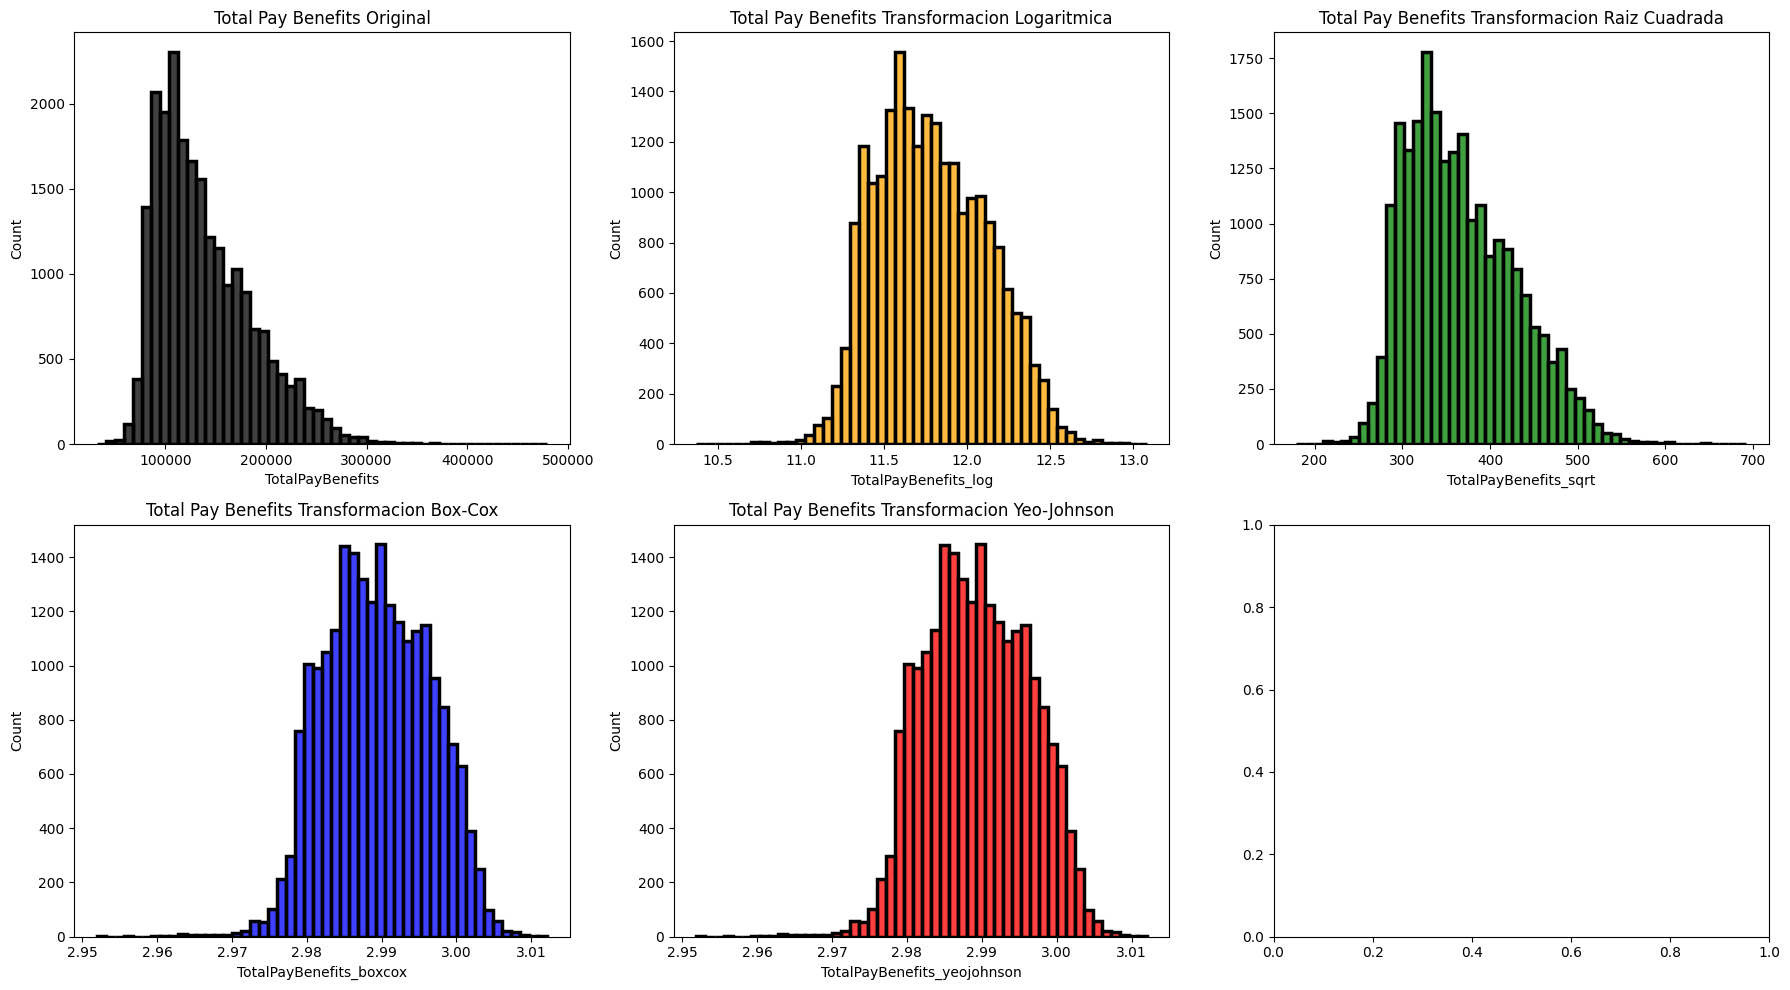

In [8]:
# Diagramas de densidad
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
# Graficar la variable original
sns.histplot(salaries_filtered["TotalPayBenefits"], ax=axes[0], color='black', linewidth=2.5, bins=50)
axes[0].set_title(f'TotalPayBenefits Original', fontsize=12)
# Graficar la variable con transformación logaritmica
sns.histplot(salaries_filtered["TotalPayBenefits_log"], ax=axes[1], color='orange', linewidth=2.5, bins=50)
axes[1].set_title(f'TotalPayBenefits Transformación Logaritmica', fontsize=12)
# Graficar la variable con transformación raíz cuadrada
sns.histplot(salaries_filtered["TotalPayBenefits_sqrt"], ax=axes[2], color='green', linewidth=2.5, bins=50)
axes[2].set_title(f'TotalPayBenefits Transformación Raiz Cuadrada', fontsize=12)
# Graficar la variable con transformación Box-Cox
sns.histplot(salaries_filtered["TotalPayBenefits_boxcox"], ax=axes[3], color='blue', linewidth=2.5, bins=50)
axes[3].set_title(f'TotalPayBenefits Transformación Box-Cox', fontsize=12)
# Graficar la variable con transformación Yeo Johnson
sns.histplot(salaries_filtered["TotalPayBenefits_yeojohnson"], ax=axes[4], color='red', linewidth=2.5, bins=50)
axes[4].set_title(f'TotalPayBenefits Transformación Yeo-Johnson', fontsize=12)
plt.tight_layout()
plt.show()



In [10]:
print(f'Skewness Original:\t {salaries_filtered["TotalPayBenefits"].skew():.3f}')
print(f'Skewness Logaritmica:\t {salaries_filtered["TotalPayBenefits_log"].skew():.3f}')
print(f'Skewness Raíz Cuadrada:\t {salaries_filtered["TotalPayBenefits_sqrt"].skew():.3f}')
print(f'Skewness Box-Cox:\t {salaries_filtered["TotalPayBenefits_boxcox"].skew():.3f}')
print(f'Skewness Yeo-Johnson:\t {salaries_filtered["TotalPayBenefits_yeojohnson"].skew():.3f}')

Skewness Original:	 1.005
Skewness Logaritmica:	 0.253
Skewness Raíz Cuadrada:	 0.613
Skewness Box-Cox:	 0.019
Skewness Yeo-Johnson:	 0.019


Conclusiones:
* Sí se observan diferencias entre los 4 métodos de transformación.
* Respecto a la forma de la distribución resultante:
  * En el caso de la transformación raíz cuadrada, se mantiene similar a la original.
  * En el caso de la transformación logarítmica, se obtiene una distribución más cercana a la distribución normal, aunque manteniendo (en menor grado) el sesgo a la derecha de la original.
  * Las transformaciones de Box-Cox y Yeo-Johnson sí muestran una distribución muy cercana a la normal.
* Respecto a la escala de la distribución resultante:
  * En el caso de la transformación raíz cuadrada, se reduce de 0 a 700 siendo el valor máximo aproximadamente la raìz cuadrada del valor en la escala original (500000).
  * En el caso de la transformación logarítmica, la escala se reduce de 0 a 13.
  * Las transformaciones de Box-Cox y Yeo-Johnson sí muestran una distribución muy cercana a la normal, entre 2.95 y 3.01
* Respecto al valor de Skewness luego de las transformaciones se observa que:
  * Box-Cox y Yeo-Johnson son cercanos a 0 (0.019) lo que confirma la forma de la distribucion cercana a la normal
  * Logarítmica tiene un valor de 0.253 cercana a 0 y manteniendo la interpretabilidad a diferencia de Box-Cox y Yeo-Johnson (tranformaciones con potencia)
  * La Raíz Cuadrada es la de mayor skeness confirmando lo visto en el diagrama de distribución


### Parte 2: Detección de datos atípicos multivariados (10 puntos)

#### 2.1 Parte teórica (5 puntos)

Responda las siguientes preguntas:

a) En el contexto de la maldición de la dimensionalidad, ¿cómo cambia la definición o interpretación de un atípico en espacios de alta dimensión y por qué ciertos métodos de detección de datos atípicos pueden volverse ineficaces? ¿Qué estrategias o enfoques pueden emplearse para mitigar este problema? (2 puntos)

b) En clase revisamos distintos métodos de detección de atípicos multivariantes, pero dicha lista no es extensiva. Otro método conocido, el cual se basada en densidades, es [**LOF (Local Outlier Factor)**](https://en.wikipedia.org/wiki/Local_outlier_factor), que estima el grado de atipicidad de un punto comparando su densidad local con la densidad de sus vecinos más cercanos. A diferencia de enfoques globales, LOF permite identificar outliers locales, es decir, puntos que son anómalos respecto a su vecindario inmediato, incluso si no lo son a nivel global. Se adjunta como hipervínculo su [paper](https://dl.acm.org/doi/epdf/10.1145/335191.335388) y su [implementación en scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.LocalOutlierFactor.html). Vamos a incluir la aplicación de este método en la pregunta 2.2.

Asimismo, existen métodos inspirados en [DBSCAN](https://file.biolab.si/papers/1996-DBSCAN-KDD.pdf) que buscan atacar sus debilidades, estos son:

- **HDBSCAN**, siglas de **H**ierarchical **D**ensity-**B**ased **S**patial **C**lustering of **A**pplications with **N**oise. Se adjunta como hipervínculo su [paper](https://arxiv.org/pdf/1911.02282).
- **OPTICS**, siglas de **O**rdering **P**oints **T**o **I**dentify the **C**lustering **S**tructure. Se adjunta como hipervínculo su [paper](https://dl.acm.org/doi/epdf/10.1145/304181.304187).

Lea (ya sea a través de los papers o en otras fuentes en internet) y, en sus propias palabras, explique qué mejoran y cómo lo hacen con respecto al DBSCAN original. (3 puntos)

a)


b)

#### 2.2 Parte práctica (5 puntos)

Vamos a emplear un dataset del sector inmobiliario, en particular, del dataset House Prices de Ames, Iowa, del cual se toman dos variables:

- LotArea: Área total del lote en pies cuadrados.
- GrLivArea: Área habitable sobre el suelo en pies cuadrados.

El objetivo es detectar valores atípicos multivariados en estos datos utilizando los siguientes métodos:

1. **Distancia de Mahalanobis** - α = 0.025
2. **Isolation Forest** - IsolationForest(contamination=0.05, random_state=42)
3. **Local Outlier Factor (LOF)** - LocalOutlierFactor(n_neighbors=20)
4. **DBSCAN** - DBSCAN(eps=350, min_samples=5)

Emplee los argumentos brindados. Realice 4 gráficos de dispersión de las variables LotArea vs GrLivArea (uno por cada método), donde los puntos rojos representen los valores atípicos detectados por cada método y los puntos azules los valores normales. Analice y comente sobre los resultados. ¿Los datos atípicos detectados por estos métodos coinciden con lo que hubieran determinado intuitivamente de manera visual?

In [35]:
data = fetch_openml(name="house_prices", as_frame=True)["data"]
data = data[["LotArea", "GrLivArea"]].dropna().astype(float)
data.head()

,LotArea,GrLivArea
0,8450.0,1710.0
1,9600.0,1262.0
2,11250.0,1786.0
3,9550.0,1717.0
4,14260.0,2198.0


In [36]:
# Se genera nuevo dataframe con copia de los datos
resultados = data.copy()

**Método de Distancia de Mahalanobis**

In [37]:
# Dectección de Atípicos con método de Mahalanobis

def mahalanobis(df, alpha):
  # Array de Valores del dataframe
  X = df.values
  # Calculo de la Media
  mu = np.mean(X, axis=0)
  # Matriz de covarianza
  cov_matrix = np.cov(X.T)
  # Inversa de la Matriz de covarianza
  cov_matrix_inv = np.linalg.inv(cov_matrix)
  # Vector de differencia
  diff = X - mu
  # Distancia de Mahalanobis
  md = np.sqrt(np.diag(diff @ cov_matrix_inv @ diff.T))
  # Umbral basado en distribución Chi-Cuadrado con 2 grados de libertad (2 variables)
  threshold = np.sqrt(chi2.ppf((1 - alpha), df=2))
  # Si distancia es mayor que umbral -> atipico (-1), caso contrario normal (1)
  return np.where(md > threshold, -1, 1)

# Ejecutar metodo de Mahalanobis
resultados["Mahalanobis"] = mahalanobis(data, 0.025)

# Calcular resultados para Mahalanobis
n_total = resultados.shape[0]
n_normales = (resultados['Mahalanobis'] == 1).sum()
n_atipicos = (resultados['Mahalanobis'] == -1).sum()
porcentaje_atipicos = round(n_atipicos / n_total * 100, 2)

# Crear Dataframe para guardar resultados
resumen_atipicos_multi = pd.DataFrame({
    'Metodo': 'Mahalanobis',
    'Totales': [n_total],
    'Normales': [n_normales],
    'Atípicos': [n_atipicos],
    '%Atípicos': [porcentaje_atipicos]
})

# Visualizar Dataframe con resultados
resumen_atipicos_multi


,Metodo,Totales,Normales,Atípicos,%Atípicos
0,Mahalanobis,1460,1427,33,2.26


**Método Isolation Forest**

In [38]:
# Dectección de Atípicos con método de Mahalanobis

from sklearn.ensemble import IsolationForest

# Ejecutar Isolation Forest con contaminación 0.05 y random state 42
isolation_forest = IsolationForest(contamination=0.05, random_state=42)
resultados['IsolationForest'] = isolation_forest.fit_predict(data)

# Calcular resultados para Isolation Forest
n_total = resultados.shape[0]
n_normales = (resultados['IsolationForest'] == 1).sum()
n_atipicos = (resultados['IsolationForest'] == -1).sum()
porcentaje_atipicos = round(n_atipicos / n_total * 100, 2)
metodo_data = {
    'Metodo': 'Isolation Forest',
    'Totales': n_total,
    'Normales': n_normales,
    'Atípicos': n_atipicos,
    '%Atípicos': porcentaje_atipicos
}

# Actualizar resumen de resultados
resumen_atipicos_multi.loc[len(resumen_atipicos_multi)] = metodo_data
resumen_atipicos_multi

,Metodo,Totales,Normales,Atípicos,%Atípicos
0,Mahalanobis,1460,1427,33,2.26
1,Isolation Forest,1460,1387,73,5.00


**Método Local Outlier Factor (LOF)**

In [39]:
# Dectección de Atípicos con método de Local Outlier Factor (LOF)

from sklearn.neighbors import LocalOutlierFactor

# Ejecutar LOF con 20 neighbors
lof = LocalOutlierFactor(n_neighbors=20)
resultados['LOF'] = lof.fit_predict(data)

# Calcular resultados para LOF
n_total = resultados.shape[0]
n_normales = (resultados['LOF'] == 1).sum()
n_atipicos = (resultados['LOF'] == -1).sum()
porcentaje_atipicos = round(n_atipicos / n_total * 100, 2)
metodo_data = {
    'Metodo': 'LOF',
    'Totales': n_total,
    'Normales': n_normales,
    'Atípicos': n_atipicos,
    '%Atípicos': porcentaje_atipicos
}

# Actualizar resumen de resultados
resumen_atipicos_multi.loc[len(resumen_atipicos_multi)] = metodo_data
resumen_atipicos_multi

,Metodo,Totales,Normales,Atípicos,%Atípicos
0,Mahalanobis,1460,1427,33,2.26
1,Isolation Forest,1460,1387,73,5.00
2,LOF,1460,1417,43,2.95


**Método DBSCAN**

In [40]:
# Dectección de Atípicos con método DBSCAN

from sklearn.cluster import DBSCAN

# Ejecutar DBSCAN con epsilon 350 y 5 muestras
db = DBSCAN(eps=350, min_samples=5)
# DBSCAN etiqueta como -1 los outliers (ruido)
resultados['DBSCAN'] = db.fit_predict(data)
# Estandarizar etiqueta -1 para atipicos, 1 para normales
resultados['DBSCAN'] = resultados['DBSCAN'].apply(lambda x: -1 if x == -1 else 1)

# Calcular resultados para DBSCAN
n_total = resultados.shape[0]
n_normales = (resultados['DBSCAN'] == 1).sum()
n_atipicos = (resultados['DBSCAN'] == -1).sum()
porcentaje_atipicos = round(n_atipicos / n_total * 100, 2)
metodo_data = {
    'Metodo': 'DBSCAN',
    'Totales': n_total,
    'Normales': n_normales,
    'Atípicos': n_atipicos,
    '%Atípicos': porcentaje_atipicos
}

# Actualizar resumen de resultados
resumen_atipicos_multi.loc[len(resumen_atipicos_multi)] = metodo_data
resumen_atipicos_multi

,Metodo,Totales,Normales,Atípicos,%Atípicos
0,Mahalanobis,1460,1427,33,2.26
1,Isolation Forest,1460,1387,73,5.00
2,LOF,1460,1417,43,2.95
3,DBSCAN,1460,1373,87,5.96


**Gráficos de Dispersión**

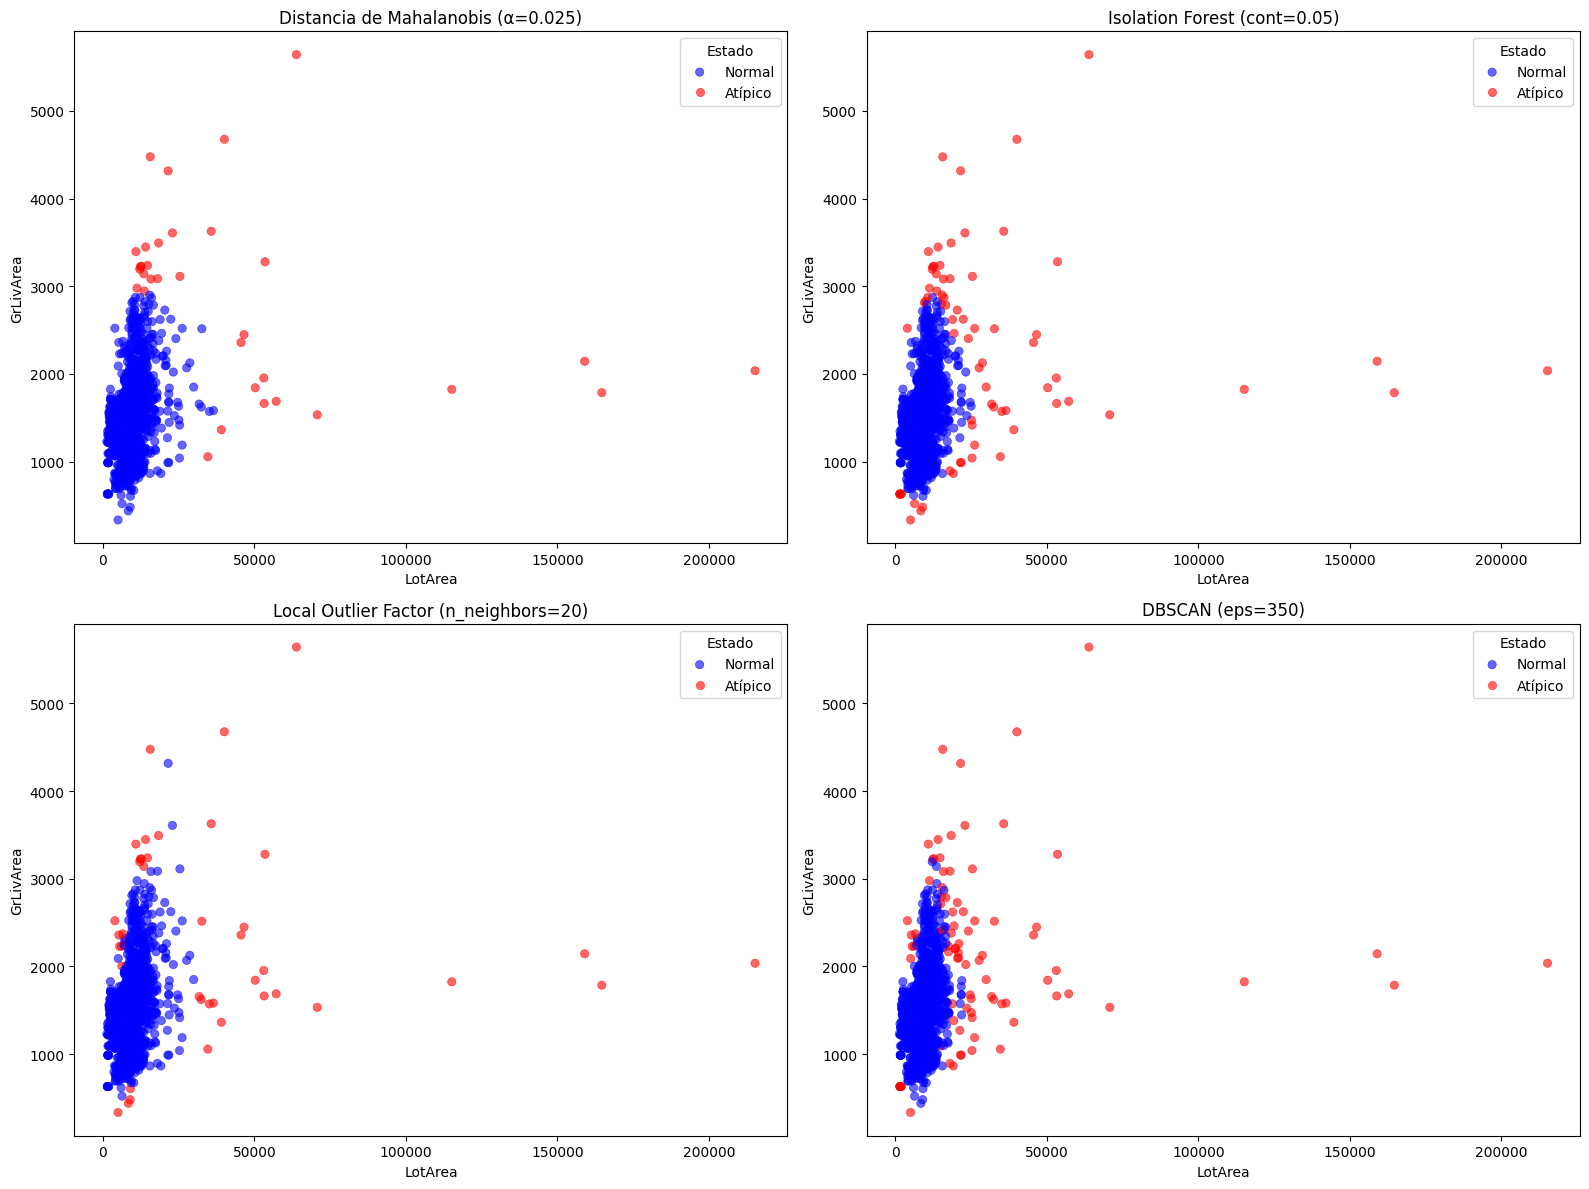

In [41]:
# Gráficos de dispersión de las variables LotArea vs GrLivArea para cada método

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
metodos = ['Mahalanobis', 'IsolationForest', 'LOF', 'DBSCAN']
titulos = ['Distancia de Mahalanobis (α=0.025)', 'Isolation Forest (cont=0.05)',
          'Local Outlier Factor (n_neighbors=20)', 'DBSCAN (eps=350)']

for i, ax in enumerate(axes.flatten()):
    metodo = metodos[i]
    sns.scatterplot(data=resultados, x='LotArea', y='GrLivArea',
                    hue=metodo, palette={1: 'blue', -1: 'red'},
                    ax=ax, alpha=0.6, edgecolor=None)
    ax.set_title(titulos[i])
    ax.legend(title='Estado', labels=['Normal', 'Atípico'])

plt.tight_layout()
plt.show()

**Conclusiones**

* Se observa que los datos atípicos detectados por los métodos empleados, coinciden parcialmente con los detectados visualmente.
* Visualmente se pueden identificar las casas con LotArea > 50,000 como atípicos. Asimismo se pueden considerar atípicos también las casas con GrLivArea > 4000.
* Sin embargo, los 4 metodos consideran atípicos casas por debajo de esos umbrales, y sobretodo en los métodos de LOF o DBSCAN se consideran algunos puntos que están "dentro" de la mayor concentración como atípicos.



### Parte 3: Calidad de datos (6 puntos)

Se presenta un dataset que contiene 200 solicitudes de crédito personal. Asimismo, se proporciona un diccionario de datos, en el cual se especifica para cada variable: el nombre de la columna, el tipo de dato, su descripción, si admite valores nulos y si posee alguna restricción.

El objetivo de este ejercicio es implementar las 10 reglas de calidad de datos indicadas en la tabla. Cabe señalar que, en base al diccionario de datos, podrían definirse muchas más reglas; sin embargo, para efectos de esta actividad, solo se deben considerar las 10 especificadas.

Como resultado final, se espera una tabla o un reporte (prints) que incluya:

- La cantidad y % de registros que incumplen cada regla de calidad.
- El id_solicitud y los valores correspondientes a los registros que presentan incumplimientos.

La implementación puede realizarse utilizando `Great Expectations` o mediante validaciones ad-hoc en código.

#### Diccionario de datos

| # | Columna | Tipo | Descripción | Ejemplo | Nulos permitidos | Restricción / Dominio |
|---|---------|------|-------------|---------|------------------|-----------------------|
| 1 | `id_solicitud` | str | Identificador único de la solicitud | `SOL-00001` | No | Formato `SOL-NNNNN` |
| 2 | `dni` | str | DNI del solicitante (Perú) | `12345678` | No | Exactamente 8 dígitos numéricos |
| 3 | `nombre` | str | Nombre completo del solicitante | `Ana García López` | No | Texto libre, no vacío |
| 4 | `fecha_nacimiento` | date | Fecha de nacimiento | `1990-03-15` | No | Fecha válida; coherente con `edad` |
| 5 | `edad` | int | Edad declarada (años) | `34` | No | Entre 18 y 80 inclusive |
| 6 | `email` | str | Correo electrónico de contacto | `ana@gmail.com` | No | Formato RFC estándar |
| 7 | `telefono` | str | Teléfono celular (Perú) | `987654321` | No | 9 dígitos, inicia en `9` |
| 8 | `ingreso_mensual` | float | Ingreso neto mensual declarado (S/) | `3500.00` | No | > 0 |
| 9 | `monto_solicitado` | float | Monto del crédito solicitado (S/) | `15000.00` | No | > 0 |
| 10 | `plazo_meses` | int | Plazo del crédito en meses | `36` | No | Uno de: {12, 24, 36, 48, 60} |
| 11 | `cuota_mensual` | float | Cuota mensual del crédito (S/) | `512.50` | No | > 0; ≤ 30 % del `ingreso_mensual` |
| 12 | `tipo_empleo` | str | Situación laboral del solicitante | `dependiente` | No | {`dependiente`, `independiente`, `desempleado`} |
| 13 | `empresa` | str | Nombre del empleador | `Empresa_SAC_012` | Sí (si no es dependiente) | Obligatorio cuando `tipo_empleo = dependiente` |
| 14 | `estado_solicitud` | str | Estado actual del trámite | `aprobada` | No | {`aprobada`, `rechazada`, `en_revision`} |
| 15 | `fecha_solicitud` | date | Fecha en que se registró la solicitud | `2024-03-20` | No | Fecha válida |
| 16 | `fecha_resolucion` | date | Fecha en que se resolvió la solicitud | `2024-03-28` | Sí (si aún en revisión) | Cuando existe: ≥ `fecha_solicitud` |

#### Reglas de calidad a implementar

| ID | Columna(s) | Descripción |
|----|-----------|-------------|
| **R1** | `dni` | El DNI peruano tiene exactamente 8 dígitos numéricos |
| **R2** | `email` | Estructura `usuario@dominio.ext` |
| **R3** | `telefono` |  Celular peruano: 9 dígitos, inicia en `9` |
| **R4** | `edad` | Menores de 18 no pueden contratar; política de riesgo limita a 80 |
| **R5** | `ingreso_mensual` | Un ingreso ≤ 0 es imposible para calificar al crédito |
| **R6** | `tipo_empleo` | Solo se aceptan tres valores codificados en el sistema |
| **R7** | `tipo_empleo` + `empresa`  | Si es `dependiente`, debe declarar obligatoriamente su empleador |
| **R8** | `fecha_solicitud` + `fecha_resolucion`  | Una solicitud no puede resolverse antes de haberse registrado |
| **R9** | `edad` + `fecha_nacimiento`  | La edad declarada debe ser coherente con la fecha de nacimiento (±1 año) |
| **R10** | `cuota_mensual` + `ingreso_mensual`  | La cuota no puede superar el 30 % del ingreso neto (Reglamento SBS Perú) |

##### Leer Dataframe

In [52]:
df_creditos=pd.read_csv("solicitudes_credito.csv", parse_dates=["fecha_nacimiento", "fecha_solicitud", "fecha_resolucion"])
df_creditos.head()

,id_solicitud,dni,nombre,fecha_nacimiento,edad,email,telefono,ingreso_mensual,monto_solicitado,plazo_meses,cuota_mensual,tipo_empleo,empresa,estado_solicitud,fecha_solicitud,fecha_resolucion
0,SOL-00001,95822412,Sofía Rivera Pérez,1965-01-01,60,usuario0@yahoo.com,953389073,3306.20,7047.62,48,207.02,dependiente,Empresa_EIRL_000,aprobada,2024-08-25,2024-08-28
1,SOL-00002,24942603,Jorge Torres Ramírez,1975-01-02,50,usuario1@gmail.com,925558733,2670.08,18637.76,36,673.80,dependiente,Empresa_SA_001,aprobada,2024-10-15,2024-10-23
2,SOL-00003,13356886,Luis Martínez Martínez,1989-01-01,36,usuario2@outlook.com,964247457,5051.93,22101.36,24,1103.39,dependiente,Empresa_EIRL_002,en_revision,2024-10-23,2024-11-21
3,SOL-00004,46913810,Luis Pérez García,1961-01-01,64,usuario3@outlook.com,979067939,2755.68,5645.25,60,143.35,dependiente,Empresa_SAC_003,aprobada,2024-08-17,2024-08-18
4,SOL-00005,42868828,Miguel Torres Martínez,1996-01-02,29,usuario4@gmail.com,910154493,4273.86,30730.78,60,780.36,dependiente,Empresa_SA_004,en_revision,2024-12-14,2024-12-27


##### Validar tipo de datos

In [53]:
df_creditos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_solicitud      200 non-null    object        
 1   dni               200 non-null    object        
 2   nombre            200 non-null    object        
 3   fecha_nacimiento  200 non-null    datetime64[ns]
 4   edad              200 non-null    int64         
 5   email             200 non-null    object        
 6   telefono          200 non-null    int64         
 7   ingreso_mensual   200 non-null    float64       
 8   monto_solicitado  200 non-null    float64       
 9   plazo_meses       200 non-null    int64         
 10  cuota_mensual     200 non-null    float64       
 11  tipo_empleo       200 non-null    object        
 12  empresa           134 non-null    object        
 13  estado_solicitud  200 non-null    object        
 14  fecha_solicitud   200 non-

Se observa que "telefono" está como entero y no string. Se convierte a tipo string

In [54]:
df_creditos['telefono'] = df_creditos['telefono'].astype('string')
df_creditos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_solicitud      200 non-null    object        
 1   dni               200 non-null    object        
 2   nombre            200 non-null    object        
 3   fecha_nacimiento  200 non-null    datetime64[ns]
 4   edad              200 non-null    int64         
 5   email             200 non-null    object        
 6   telefono          200 non-null    string        
 7   ingreso_mensual   200 non-null    float64       
 8   monto_solicitado  200 non-null    float64       
 9   plazo_meses       200 non-null    int64         
 10  cuota_mensual     200 non-null    float64       
 11  tipo_empleo       200 non-null    object        
 12  empresa           134 non-null    object        
 13  estado_solicitud  200 non-null    object        
 14  fecha_solicitud   200 non-

Importar librerias requeridas y crear tabla para registro de errores

In [55]:
import re
from datetime import datetime

tabla_errores = pd.DataFrame(columns=['id_solicitud', 'regla', 'valor'])

Regla 1: DNI (8 dígitos numéricos)

In [56]:
# R1: DNI (8 dígitos numéricos)

regex_r1 = r'^\d{8}$'
mask_r1 = ~df_creditos['dni'].str.match(regex_r1)

for index, row in df_creditos[mask_r1].iterrows():
    # Calcular resultados para DBSCAN
    registro_error = {'id_solicitud': row['id_solicitud'],'regla': 'R1','valor': row['dni']}
    # Actualizar resumen de resultados
    tabla_errores.loc[len(tabla_errores)] = registro_error

Regla 2: Email (Estructura usuario@dominio.ext)

In [57]:
# R2: Email (Estructura usuario@dominio.ext)

regex_r2 = r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$'
mask_r2 = ~df_creditos['email'].str.match(regex_r2)

for index, row in df_creditos[mask_r2].iterrows():
    # Calcular resultados para DBSCAN
    registro_error = {'id_solicitud': row['id_solicitud'],'regla': 'R2','valor': row['email']}
    # Actualizar resumen de resultados
    tabla_errores.loc[len(tabla_errores)] = registro_error

R3: Teléfono (9 dígitos inicia en 9)

In [58]:
# R3: Teléfono (9 dígitos inicia en 9)

regex_r3 = r'^9\d{8}$'
mask_r3 = ~df_creditos['telefono'].str.match(regex_r3)

for index, row in df_creditos[mask_r3].iterrows():
    # Calcular resultados para DBSCAN
    registro_error = {'id_solicitud': row['id_solicitud'],'regla': 'R3','valor': row['telefono']}
    # Actualizar resumen de resultados
    tabla_errores.loc[len(tabla_errores)] = registro_error

R4: Edad (de 18 a 80 años)

In [59]:
# R4: Edad (de 18 a 80 años)

mask_r4 = (df_creditos['edad'] < 18) | (df_creditos['edad'] > 80)

for index, row in df_creditos[mask_r4].iterrows():
    # Generar registro de error
    registro_error = {'id_solicitud': row['id_solicitud'],'regla': 'R4','valor': row['edad']}
    # Actualizar tabla de errores
    tabla_errores.loc[len(tabla_errores)] = registro_error

R5: Ingreso mensual > 0

In [60]:
# R5: Ingreso mensual > 0

mask_r5 = df_creditos['ingreso_mensual'] <= 0

for index, row in df_creditos[mask_r5].iterrows():
    # Generar registro de error
    registro_error = {'id_solicitud': row['id_solicitud'],'regla': 'R5','valor': row['ingreso_mensual']}
    # Actualizar tabla de errores
    tabla_errores.loc[len(tabla_errores)] = registro_error

R6: Tipo empleo (con 3 valores permitidos: dependiente, independiente, desempleado)

In [61]:
# R6: Tipo empleo (con 3 valores permitidos: dependiente, independiente, desempleado)

tipos_empleo = ['dependiente', 'independiente', 'desempleado']
mask_r6 = ~df_creditos['tipo_empleo'].isin(tipos_empleo)

for index, row in df_creditos[mask_r6].iterrows():
    # Generar registro de error
    registro_error = {'id_solicitud': row['id_solicitud'],'regla': 'R6','valor': row['tipo_empleo']}
    # Actualizar tabla de errores
    tabla_errores.loc[len(tabla_errores)] = registro_error

R7: Tipo empleo + empresa (Si dependiente -> empresa != None)

In [62]:
# R7: Tipo empleo + empresa (Si dependiente -> empresa != None)

mask_r7 = (df_creditos['tipo_empleo'] == 'dependiente') & (df_creditos['empresa'].isna())

for index, row in df_creditos[mask_r7].iterrows():
    # Generar registro de error
    registro_error = {'id_solicitud': row['id_solicitud'],'regla': 'R7','valor': str(row['tipo_empleo']) + '/' + str({row['empresa']})}
    # Actualizar tabla de errores
    tabla_errores.loc[len(tabla_errores)] = registro_error

R8: Fecha_solicitud + Fecha_resolucion (Resolución >= Solicitud)

In [63]:
# R8: Fecha_solicitud + Fecha_resolucion (Resolución >= Solicitud)

mask_r8 = (df_creditos['fecha_resolucion'].notna()) & (df_creditos['fecha_resolucion'] < df_creditos['fecha_solicitud'])

for index, row in df_creditos[mask_r8].iterrows():
    # Generar registro de error
    registro_error = {'id_solicitud': row['id_solicitud'],'regla': 'R8','valor': str(row['fecha_solicitud'].date()) + '/' + str(row['fecha_resolucion'].date())}
    # Actualizar tabla de errores
    tabla_errores.loc[len(tabla_errores)] = registro_error

R9: Edad + Fecha Nacimiento (Edad coherente con fecha naciemiento ±1 año)

In [64]:
# R9: Edad + Fecha Nacimiento (Edad coherente con fecha naciemiento ±1 año)

# Calcular edad teórica: (Fecha actual o de solicitud - Nacimiento)
df_creditos['edad_calculada'] = df_creditos['fecha_solicitud'].dt.year - df_creditos['fecha_nacimiento'].dt.year
mask_r9 = abs(df_creditos['edad'] - df_creditos['edad_calculada']) > 1

for index, row in df_creditos[mask_r9].iterrows():
    # Generar registro de error
    registro_error = {'id_solicitud': row['id_solicitud'],'regla': 'R9','valor': str(row['edad']) + '/' + str(row['fecha_nacimiento'].date())}
    # Actualizar tabla de errores
    tabla_errores.loc[len(tabla_errores)] = registro_error

R10: Cuota Mensual + Ingreso Mensual (Cuota <= 30% Ingreso)

In [65]:
# R10: Cuota Mensual + Ingreso Mensual (Cuota <= 30% Ingreso)

mask_r10 = df_creditos['cuota_mensual'] > (df_creditos['ingreso_mensual'] * 0.30)

for index, row in df_creditos[mask_r10].iterrows():
    # Generar registro de error
    registro_error = {'id_solicitud': row['id_solicitud'],'regla': 'R10','valor': str(row['cuota_mensual']) + '/' + str(row['ingreso_mensual'])}
    # Actualizar tabla de errores
    tabla_errores.loc[len(tabla_errores)] = registro_error

Reporte de cantidad y % de registros que no cumplen reglas de calidad

In [70]:
# Tabla resumen de calidad de datos
tabla_resumen = tabla_errores.groupby('regla').size().reset_index(name='incumplimientos')
tabla_resumen['porcentaje'] = (tabla_resumen['incumplimientos'] / len(df_creditos)) * 100
print('### Reporte Resumen de Calidad de Datos ###')
tabla_resumen

### Reporte Resumen de Calidad de Datos ###


,regla,incumplimientos,porcentaje
0,R1,5,2.5
1,R10,50,25.0
2,R2,4,2.0
3,R3,3,1.5
4,R4,3,1.5
5,R5,2,1.0
6,R6,2,1.0
7,R7,1,0.5
8,R8,3,1.5
9,R9,3,1.5


Reporte de registros que no cumplen reglas de calidad

In [73]:
# Tabla incumplimientos de calidad de datos
print('### Reporte Registros que no cumplen Calidad de Datos ###')
print(tabla_errores.to_string(index=False))

### Reporte Registros que no cumplen Calidad de Datos ###
id_solicitud regla                 valor
   SOL-00006    R1               1234567
   SOL-00024    R1              ABC12345
   SOL-00068    R1            1234567890
   SOL-00103    R1             12-345678
   SOL-00146    R1              12 34567
   SOL-00009    R2    sinArrobapunto.com
   SOL-00034    R2              usuario@
   SOL-00078    R2          @dominio.com
   SOL-00121    R2          usuario@.com
   SOL-00013    R3                 12345
   SOL-00057    R3            8123456789
   SOL-00090    R3            9999999999
   SOL-00016    R4                    17
   SOL-00031    R4                    82
   SOL-00076    R4                    16
   SOL-00026    R5                -800.0
   SOL-00061    R5                   0.0
   SOL-00008    R6             freelance
   SOL-00056    R6              jubilado
   SOL-00006    R7     dependiente/{nan}
   SOL-00011    R8 2024-11-17/2024-11-11
   SOL-00046    R8 2024-11-29/2024-11-19